# 🔍 Explainable AI (XAI) — Hybrid Recommender System

**Pipeline:**
```
JSON request
  → convert to model input
  → run hybrid recommender (single pass)
  → capture intermediate signals (cf_series, content_series)
  → score breakdown (CF score, Content score, Hybrid score)
  → CF explanation  (similar users who liked the item)
  → Content explanation (genre / keyword similarity)
  → SHAP + LIME for content features
  → Non-hybrid model explainability (User-KNN, Item-KNN, BoW, TF-IDF)
```

**Design principle:** The hybrid model runs **once**. We capture `cf_series` and  
`content_series` as intermediate signals and explain from those — no redundant passes.

---

## 0 · Environment & Imports

In [3]:
# ── install dependencies if needed (comment out after first run) ──────────────
!pip install shap lime matplotlib seaborn --quiet

In [7]:
from __future__ import annotations

import sys, json, pickle, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')

# ── project paths ─────────────────────────────────────────────────────────────
# Adjust ROOT to wherever your project lives
ROOT        = Path('..').resolve()          # project root
DATA_RAW    = ROOT / 'data' / 'raw'
DATA_PROC   = ROOT / 'data' / 'processed'
MODELS_DIR  = ROOT / 'models'
HYBRID_DIR  = ROOT / 'HybridModel/models'              # where H1_hybrid_*.pkl live
RESULTS_DIR = ROOT / 'results'
FIGURES_DIR = ROOT / 'figures'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── make utils importable ─────────────────────────────────────────────────────
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils_hybrid      import hybrid_scores_for_user, GENRE_COLS
from utils_recommender import explain_content_recommendation, explain_bow_content_recommendation

print('✅  Imports OK')
print(f'   ROOT      = {ROOT}')
print(f'   MODELS    = {MODELS_DIR}')
print(f'   HYBRID    = {HYBRID_DIR}')

✅  Imports OK
   ROOT      = /Users/moustafa/new_Xplaina/XplainaV301
   MODELS    = /Users/moustafa/new_Xplaina/XplainaV301/models
   HYBRID    = /Users/moustafa/new_Xplaina/XplainaV301/HybridModel/models


---
## 1 · Load All Artefacts

We load every pickle produced by the training notebooks so the explainability  
pipeline is completely self-contained — no CSV re-reads, no re-training.

In [8]:
def _load(path: Path, label: str):
    """Load a pickle and print a friendly status line."""
    path = Path(path)
    if not path.exists():
        print(f'  ⚠️  NOT FOUND — {label} ({path})')
        return None
    with open(path, 'rb') as f:
        obj = pickle.load(f)
    print(f'  ✅  {label:30s} ← {path.name}')
    return obj

print('Loading artefacts …')

# ── Hybrid artefacts ──────────────────────────────────────────────────────────
hybrid_meta      = _load(HYBRID_DIR / 'H1_hybrid_meta.pkl',       'hybrid_meta')
hybrid_recs_best = _load(HYBRID_DIR / 'H1_hybrid_recs_best.pkl',  'hybrid_recs_best')
sim_df_tfidf     = _load(HYBRID_DIR / 'H1_sim_df_tfidf.pkl',      'sim_df_tfidf (H1)')

# ── Non-hybrid artefacts ──────────────────────────────────────────────────────
pred_user_knn    = _load(MODELS_DIR / '06_pred_user_knn.pkl',      'pred_user_knn')
pred_item_knn    = _load(MODELS_DIR / '06_pred_item_knn.pkl',      'pred_item_knn')
tfidf_similarity = _load(MODELS_DIR / 'tfidf_similarity.pkl',      'tfidf_similarity')
bow_similarity   = _load(MODELS_DIR / 'bow_similarity.pkl',        'bow_similarity')

# ── Meta unpacking ────────────────────────────────────────────────────────────
if hybrid_meta:
    BEST_ALPHA  = hybrid_meta['best_alpha']
    TOP_N       = hybrid_meta['top_n']
    CF_MODEL    = hybrid_meta['cf_model']
    CONTENT_MODEL = hybrid_meta['content_model']
    print(f'\n📋  Hybrid meta: alpha={BEST_ALPHA}, top_n={TOP_N}')
    print(f'   CF model      : {CF_MODEL}')
    print(f'   Content model : {CONTENT_MODEL}')
else:
    BEST_ALPHA, TOP_N = 0.5, 10
    CF_MODEL, CONTENT_MODEL = 'User-KNN (k=20)', 'TF-IDF cosine similarity'
    print('⚠️  hybrid_meta missing — using defaults.')

Loading artefacts …
  ✅  hybrid_meta                    ← H1_hybrid_meta.pkl
  ✅  hybrid_recs_best               ← H1_hybrid_recs_best.pkl
  ✅  sim_df_tfidf (H1)              ← H1_sim_df_tfidf.pkl
  ✅  pred_user_knn                  ← 06_pred_user_knn.pkl
  ✅  pred_item_knn                  ← 06_pred_item_knn.pkl
  ✅  tfidf_similarity               ← tfidf_similarity.pkl
  ✅  bow_similarity                 ← bow_similarity.pkl

📋  Hybrid meta: alpha=0.5, top_n=10
   CF model      : User-KNN (k=20)
   Content model : TF-IDF cosine similarity


In [9]:
# ── Load training / test data (needed for CF neighbour lookups) ───────────────
ratings_full = pd.read_csv(DATA_PROC / 'ratings_full_with_predictions.csv')
courses_df   = pd.read_csv(DATA_PROC / 'final_courses.csv')

# Reconstruct train / test split with the same seed used in H1
from utils_hybrid import train_test_split_by_user
train_df, test_df = train_test_split_by_user(ratings_full, min_user_ratings=5,
                                              test_size=0.2, seed=42)
train_utility = train_df.pivot_table(index='user', columns='item', values='rating')

print(f'train shape : {train_df.shape}')
print(f'test  shape : {test_df.shape}')
print(f'users       : {train_df["user"].nunique()}')
print(f'items       : {train_df["item"].nunique()}')

train shape : (189876, 3)
test  shape : (43611, 3)
users       : 34082
items       : 307


---
## 2 · JSON Input → Model Input

In production the caller sends a JSON payload.  
This cell converts it into the internal representation the recommender needs.

In [10]:
# ── Identify valid real users ─────────────────────────────────────────────────
# Real users have positive IDs. Negative IDs are synthetic users created by
# append_predicted_courses_to_ratings() during training.
# We also require the user to exist in pred_user_knn (CF predictions).
known_users = set(train_df['user'].unique())
cf_users    = set(pred_user_knn.keys()) if pred_user_knn else set()
real_users  = sorted([u for u in known_users & cf_users if u > 0])

if not real_users:
    # Fallback: include all users with CF predictions (even synthetic negatives)
    real_users = sorted([u for u in known_users & cf_users])

print(f'Real users with CF predictions : {len(real_users)}')
print(f'First 10 valid user IDs        : {real_users[:10]}')
print()
print('To use a specific user, set MANUAL_USER_ID = real_users[N] or an explicit ID.')
print('Leave it as None to auto-select the first valid user.')
print()

# ── Set this to a specific user ID, or leave as None for auto-select ──────────
MANUAL_USER_ID = None   # e.g. MANUAL_USER_ID = real_users[3]

# ── Build the simulated production JSON request ───────────────────────────────
chosen_user = MANUAL_USER_ID if MANUAL_USER_ID is not None else real_users[0]
REQUEST_JSON = json.dumps({
    'user_id': chosen_user,
    'top_n'  : 10,
    'alpha'  : None
})

# ── Parse ─────────────────────────────────────────────────────────────────────
request   = json.loads(REQUEST_JSON)
USER_ID   = request['user_id']
TOP_N_REQ = request.get('top_n', TOP_N)
ALPHA     = request['alpha'] if request['alpha'] is not None else BEST_ALPHA

# ── Validate ──────────────────────────────────────────────────────────────────
if USER_ID not in known_users:
    raise ValueError(
        f'User {USER_ID} not in training data.\n'
        f'Valid real users (first 20): {real_users[:20]}'
    )
if pred_user_knn and USER_ID not in pred_user_knn:
    raise ValueError(
        f'User {USER_ID} has no CF predictions.\n'
        f'Valid real users (first 20): {real_users[:20]}'
    )

print(f'Request parsed')
print(f'   user_id : {USER_ID}')
print(f'   top_n   : {TOP_N_REQ}')
print(f'   alpha   : {ALPHA}  (CF weight)')


Real users with CF predictions : 33901
First 10 valid user IDs        : [2, 4, 5, 7, 8, 9, 12, 16, 17, 19]

To use a specific user, set MANUAL_USER_ID = real_users[N] or an explicit ID.
Leave it as None to auto-select the first valid user.

Request parsed
   user_id : 2
   top_n   : 10
   alpha   : 0.5  (CF weight)


---
## 3 · Single Hybrid Pass — Capture Intermediate Signals

We call `hybrid_scores_for_user` **once** with `return_components=True`.  
This gives us `cf_full` and `content_full` — the raw CF and content signal  
vectors before blending — without any redundant computation.

In [11]:
result = hybrid_scores_for_user(
    user             = USER_ID,
    train_df         = train_df,
    cf_predictions   = pred_user_knn,
    sim_df           = sim_df_tfidf,
    alpha            = ALPHA,
    top_n            = TOP_N_REQ,
    normalize        = True,
    return_components= True,        # ← single-pass component capture
)

hybrid_top    = result['hybrid_top']    # pd.Series — top-N final recs
hybrid_full   = result['hybrid_full']   # pd.Series — all unseen items
cf_full       = result['cf_full']       # pd.Series — CF scores (normalized)
content_full  = result['content_full']  # pd.Series — Content scores (normalized)
seen_items    = result['seen_items']    # list — items user has already rated

print(f'\n🎯  Top-{TOP_N_REQ} recommendations for user {USER_ID}:')
top_df = hybrid_top.reset_index()
top_df.columns = ['COURSE_ID', 'hybrid_score']
top_df = top_df.merge(courses_df[['COURSE_ID', 'TITLE'] + GENRE_COLS], on='COURSE_ID', how='left')
top_df.insert(1, 'cf_score',      top_df['COURSE_ID'].map(cf_full))
top_df.insert(2, 'content_score', top_df['COURSE_ID'].map(content_full))
top_df.index = range(1, len(top_df) + 1)
display(top_df[['COURSE_ID', 'TITLE', 'cf_score', 'content_score', 'hybrid_score']])


🎯  Top-10 recommendations for user 2:


,COURSE_ID,TITLE,cf_score,content_score,hybrid_score
1,BD0111EN,hadoop 101,1.0,0.910818,0.955409
2,TA0105EN,text analytics 101,1.0,0.727025,0.863513
3,ML0115EN,deep learning 101,1.0,0.720599,0.860299
4,BD0212EN,spark fundamentals ii,1.0,0.644693,0.822346
5,DB0151EN,nosql and dbaas 101,1.0,0.578879,0.789439
6,RP0101EN,r for data science,1.0,0.529995,0.764998
7,ML0101EN,machine learning with python,1.0,0.511777,0.755888
8,DS0101EN,introduction to data science,1.0,0.479090,0.739545
9,ML0101ENv3,machine learning with python,1.0,0.417969,0.708984
10,BD0115EN,mapreduce and yarn,1.0,0.326909,0.663454


---
## 4 · Score Breakdown Visualisation

  Saved → /Users/moustafa/new_Xplaina/XplainaV301/figures/xai_score_breakdown_user2.png


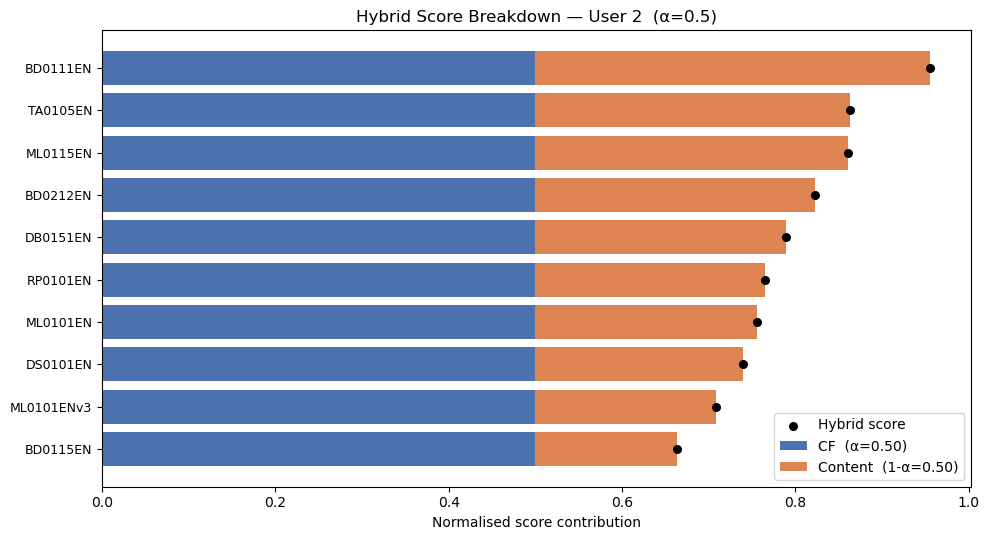

In [12]:
def plot_score_breakdown(top_df: pd.DataFrame, user_id: int, alpha: float,
                         save_dir: Path | None = None):
    """
    Stacked horizontal bar showing CF vs Content contribution for each
    recommended item, with the hybrid score overlaid as a dot.
    """
    df = top_df.copy().sort_values('hybrid_score')
    labels  = df['COURSE_ID'].astype(str)
    cf_vals = (df['cf_score']      * alpha).fillna(0)
    cb_vals = (df['content_score'] * (1 - alpha)).fillna(0)
    hy_vals = df['hybrid_score'].fillna(0)

    fig, ax = plt.subplots(figsize=(10, max(5, len(df) * 0.55)))
    y = np.arange(len(df))

    ax.barh(y, cf_vals, color='#4C72B0', label=f'CF  (α={alpha:.2f})')
    ax.barh(y, cb_vals, left=cf_vals, color='#DD8452',
            label=f'Content  (1-α={1-alpha:.2f})')
    ax.scatter(hy_vals, y, color='black', zorder=5, s=30, label='Hybrid score')

    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Normalised score contribution')
    ax.set_title(f'Hybrid Score Breakdown — User {user_id}  (α={alpha})', fontsize=12)
    ax.legend(loc='lower right')
    plt.tight_layout()

    if save_dir:
        p = Path(save_dir) / f'xai_score_breakdown_user{user_id}.png'
        plt.savefig(p, bbox_inches='tight', dpi=120)
        print(f'  Saved → {p}')
    plt.show()

plot_score_breakdown(top_df, USER_ID, ALPHA, save_dir=FIGURES_DIR)

---
## 5 · CF Explanation — "Users like you also liked …"

For the **top recommended item** we find the k most similar users,  
show their ratings on that item and their similarity to the query user.

In [13]:
def explain_cf_neighbours(
    user_id: int,
    item_id: str,
    train_utility: pd.DataFrame,
    k: int = 20,
    top_contributors: int = 5,
) -> dict:
    """
    Return the k nearest neighbours of user_id and their rating of item_id.
    Filters to neighbours who actually rated the item (non-zero / non-NaN).
    """
    users = train_utility.index.tolist()
    mat   = train_utility.fillna(0).values.astype(np.float32)

    if user_id not in users:
        return {'error': f'User {user_id} not in utility matrix.'}
    if item_id not in train_utility.columns:
        return {'error': f'Item {item_id} not in utility matrix.'}

    u_idx = users.index(user_id)
    knn = NearestNeighbors(n_neighbors=min(k + 1, len(users)),
                           metric='cosine', algorithm='brute')
    knn.fit(mat)
    dists, idxs = knn.kneighbors([mat[u_idx]])

    neighbours = [users[i] for i in idxs[0][1:]]
    sims       = 1 - dists[0][1:]
    ratings    = np.array([
        train_utility.loc[n, item_id]
        if (n in train_utility.index and item_id in train_utility.columns)
        else np.nan
        for n in neighbours
    ])

    df = pd.DataFrame({'neighbour': neighbours,
                       'similarity': sims,
                       'rating_on_item': ratings})
    df_rated = df.dropna(subset=['rating_on_item'])
    df_rated = df_rated[df_rated['rating_on_item'] > 0].nlargest(top_contributors, 'similarity')

    weighted = (df_rated['similarity'] * df_rated['rating_on_item']).sum()
    weight   = df_rated['similarity'].sum()
    predicted = weighted / weight if weight > 0 else 0.0

    return {
        'user': user_id,
        'item': item_id,
        'top_contributors': df_rated.reset_index(drop=True),
        'predicted_rating': float(predicted),
        'narrative': (
            f"User {user_id} is recommended '{item_id}' because "
            f"{len(df_rated)} similar user(s) rated it highly. "
            f"Weighted predicted rating: {predicted:.2f}."
        )
    }


# ── Run for the #1 recommended item ──────────────────────────────────────────
TOP_ITEM   = hybrid_top.index[0]
cf_explain = explain_cf_neighbours(USER_ID, TOP_ITEM, train_utility, k=20, top_contributors=5)

print('\n📣  CF Explanation')
print(f'   {cf_explain["narrative"]}')
print()
if 'top_contributors' in cf_explain and not cf_explain['top_contributors'].empty:
    display(cf_explain['top_contributors'])
else:
    print('   ⚠️  No neighbours with a rating on this item found.')


📣  CF Explanation
   User 2 is recommended 'BD0111EN' because 5 similar user(s) rated it highly. Weighted predicted rating: 3.00.



,neighbour,similarity,rating_on_item
0,335747,0.655829,3.0
1,900085,0.637237,3.0
2,491131,0.635720,3.0
3,339918,0.623816,3.0
4,924030,0.620296,3.0


  Saved → /Users/moustafa/new_Xplaina/XplainaV301/figures/xai_cf_neighbours_user2.png


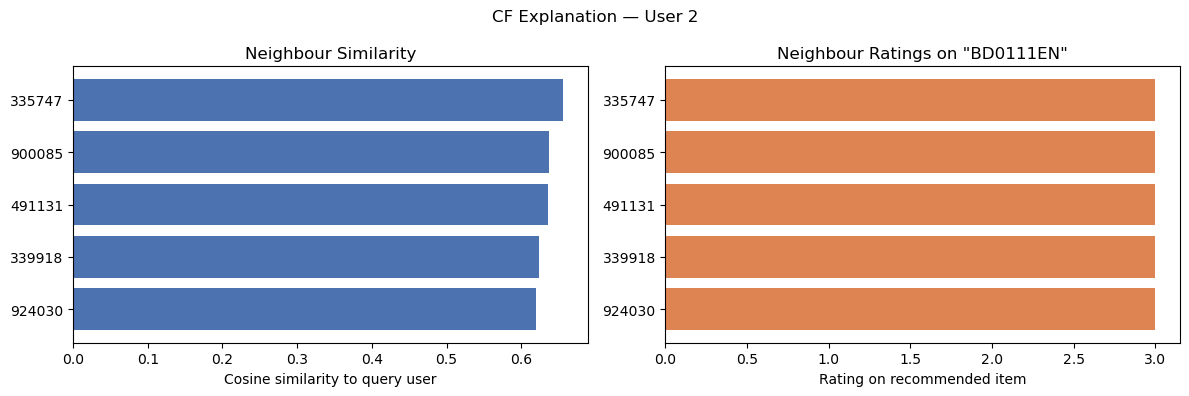

In [14]:
def plot_cf_neighbours(cf_explain: dict, save_dir: Path | None = None):
    df = cf_explain.get('top_contributors')
    if df is None or df.empty:
        print('No CF contributors to plot.')
        return

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Similarity bar
    axes[0].barh(df['neighbour'].astype(str), df['similarity'], color='#4C72B0')
    axes[0].set_xlabel('Cosine similarity to query user')
    axes[0].set_title('Neighbour Similarity')
    axes[0].invert_yaxis()

    # Rating bar
    axes[1].barh(df['neighbour'].astype(str), df['rating_on_item'], color='#DD8452')
    axes[1].set_xlabel('Rating on recommended item')
    axes[1].set_title(f'Neighbour Ratings on "{cf_explain["item"]}"')
    axes[1].invert_yaxis()

    fig.suptitle(f'CF Explanation — User {cf_explain["user"]}', fontsize=12)
    plt.tight_layout()
    if save_dir:
        p = Path(save_dir) / f'xai_cf_neighbours_user{cf_explain["user"]}.png'
        plt.savefig(p, bbox_inches='tight', dpi=120)
        print(f'  Saved → {p}')
    plt.show()

plot_cf_neighbours(cf_explain, save_dir=FIGURES_DIR)

---
## 6 · Content-Based Explanation — Genre / Keyword Similarity

In [15]:
def explain_content_features(
    user_id: int,
    item_id: str,
    train_df: pd.DataFrame,
    sim_df: pd.DataFrame,
    courses_df: pd.DataFrame,
    genre_cols: list[str],
    top_k: int = 5,
) -> dict:
    """
    Content explanation:
      1. Which of the user's seen items are most similar to item_id?
      2. Which genres does the recommended item share with those similar seen items?
    """
    user_items = [
        i for i in train_df.loc[train_df['user'] == user_id, 'item']
        if i in sim_df.index
    ]
    if not user_items or item_id not in sim_df.index:
        return {'error': 'Insufficient data for content explanation.'}

    sims = {seen: float(sim_df.loc[item_id, seen]) for seen in user_items}
    top_similar = sorted(sims.items(), key=lambda x: x[1], reverse=True)[:top_k]

    # Genre overlap
    rec_genres = set(
        g for g in genre_cols
        if item_id in courses_df['COURSE_ID'].values
        and courses_df.loc[courses_df['COURSE_ID'] == item_id, g].values[0] == 1
    )
    shared_genres_per_item = {}
    for seen_item, _ in top_similar:
        if seen_item in courses_df['COURSE_ID'].values:
            seen_genres = set(
                g for g in genre_cols
                if courses_df.loc[courses_df['COURSE_ID'] == seen_item, g].values[0] == 1
            )
            shared_genres_per_item[seen_item] = rec_genres & seen_genres

    all_shared = set().union(*shared_genres_per_item.values()) if shared_genres_per_item else set()

    return {
        'user': user_id,
        'item': item_id,
        'item_genres': sorted(rec_genres),
        'top_similar_seen': top_similar,
        'shared_genres': {k: sorted(v) for k, v in shared_genres_per_item.items()},
        'all_shared_genres': sorted(all_shared),
        'avg_similarity': float(np.mean([s for _, s in top_similar])),
        'narrative': (
            f"'{item_id}' is recommended because it shares the genre(s) "
            f"{sorted(all_shared)} with courses the user has already engaged with, "
            f"giving an average similarity of {np.mean([s for _, s in top_similar]):.3f}."
        )
    }


content_explain = explain_content_features(
    USER_ID, TOP_ITEM, train_df, sim_df_tfidf, courses_df, GENRE_COLS
)

print('\n📣  Content Explanation')
print(f'   {content_explain.get("narrative", content_explain.get("error"))}\n')
print(f'   Recommended item genres : {content_explain.get("item_genres")}')
print(f'   Shared genres           : {content_explain.get("all_shared_genres")}')
print(f'\n   Top similar seen items  :')
for item, sim in content_explain.get('top_similar_seen', []):
    shared = content_explain['shared_genres'].get(item, [])
    print(f'     {item:40s}  sim={sim:.3f}  shared={shared}')


📣  Content Explanation
   'BD0111EN' is recommended because it shares the genre(s) ['BigData', 'Database'] with courses the user has already engaged with, giving an average similarity of 0.553.

   Recommended item genres : ['BigData', 'Database']
   Shared genres           : ['BigData', 'Database']

   Top similar seen items  :
     BD0131EN                                  sim=0.598  shared=['BigData', 'Database']
     BD0101EN                                  sim=0.586  shared=['BigData', 'Database']
     BD0145EN                                  sim=0.565  shared=['BigData', 'Database']
     RP0151EN                                  sim=0.516  shared=[]
     BD0141EN                                  sim=0.499  shared=['BigData', 'Database']


  Saved → /Users/moustafa/new_Xplaina/XplainaV301/figures/xai_content_user2.png


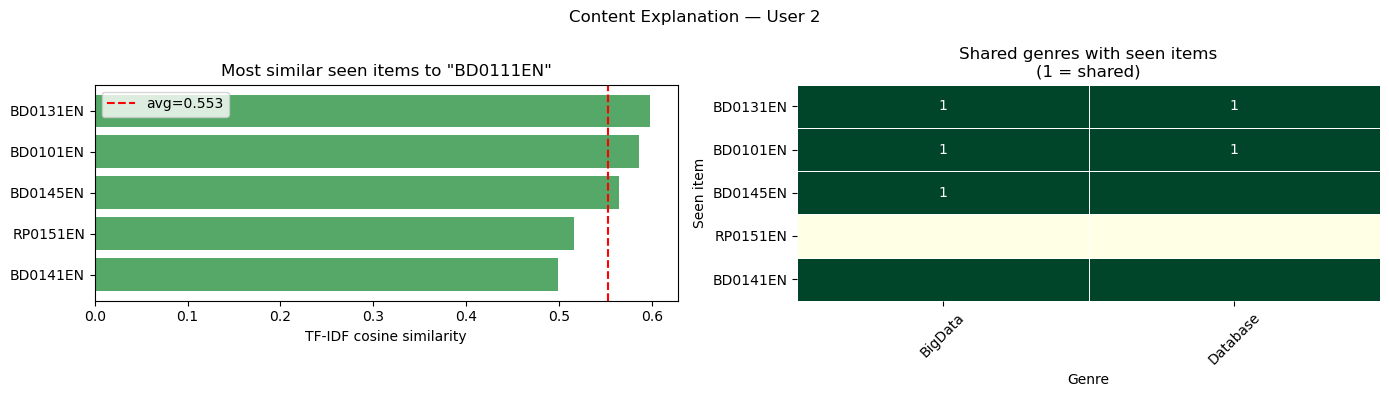

In [16]:
def plot_content_explanation(content_explain: dict, save_dir: Path | None = None):
    if 'error' in content_explain:
        print(content_explain['error'])
        return

    items = [i for i, _ in content_explain['top_similar_seen']]
    sims  = [s for _, s in content_explain['top_similar_seen']]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # ── Similarity bar ────────────────────────────────────────────────────────
    axes[0].barh(items[::-1], sims[::-1], color='#55A868')
    axes[0].set_xlabel('TF-IDF cosine similarity')
    axes[0].set_title(f'Most similar seen items to "{content_explain["item"]}"')
    axes[0].axvline(content_explain['avg_similarity'], color='red',
                    linestyle='--', label=f'avg={content_explain["avg_similarity"]:.3f}')
    axes[0].legend()

    # ── Genre heatmap ─────────────────────────────────────────────────────────
    genres_present = content_explain['item_genres']
    if genres_present and items:
        hm_data = pd.DataFrame(index=items, columns=genres_present)
        for item in items:
            row_genres = content_explain['shared_genres'].get(item, [])
            for g in genres_present:
                hm_data.loc[item, g] = 1 if g in row_genres else 0
        hm_data = hm_data.astype(int)
        sns.heatmap(hm_data, ax=axes[1], cmap='YlGn', linewidths=0.5,
                    annot=True, cbar=False, fmt='d')
        axes[1].set_title('Shared genres with seen items\n(1 = shared)')
        axes[1].set_xlabel('Genre')
        axes[1].set_ylabel('Seen item')
        axes[1].tick_params(axis='x', rotation=45)
    else:
        axes[1].text(0.5, 0.5, 'No shared genres found', ha='center', va='center')
        axes[1].axis('off')

    fig.suptitle(f'Content Explanation — User {content_explain["user"]}', fontsize=12)
    plt.tight_layout()
    if save_dir:
        p = Path(save_dir) / f'xai_content_user{content_explain["user"]}.png'
        plt.savefig(p, bbox_inches='tight', dpi=120)
        print(f'  Saved → {p}')
    plt.show()

plot_content_explanation(content_explain, save_dir=FIGURES_DIR)

---
## 7 · SHAP — Feature Importance for Content-Based Scores

We treat each item's genre vector as a feature matrix and train a  
lightweight Ridge regressor to approximate the content score.  
SHAP then attributes the content score to each genre/feature.

In [17]:
import shap
from sklearn.linear_model import Ridge

shap.initjs()

def build_content_shap_explainer(
    user_id: int,
    train_df: pd.DataFrame,
    sim_df: pd.DataFrame,
    courses_df: pd.DataFrame,
    genre_cols: list[str],
):
    """
    Fit a Ridge regressor: genre_vector → content_score.
    Returns (explainer, shap_values, X_df, content_scores).
    """
    # Build feature matrix — one row per unseen item
    user_items = [
        i for i in train_df.loc[train_df['user'] == user_id, 'item']
        if i in sim_df.index
    ]
    if not user_items:
        raise ValueError('User has no seen items in sim_df.')

    content_scores = sim_df.loc[user_items].mean(axis=0)
    content_scores = content_scores.drop(labels=[
        i for i in user_items if i in content_scores.index
    ], errors='ignore')

    # Align with courses_df
    common = [c for c in content_scores.index if c in courses_df['COURSE_ID'].values]
    if not common:
        raise ValueError('No common items between content scores and courses_df.')

    X = (
        courses_df.set_index('COURSE_ID')
        .loc[common, genre_cols]
        .fillna(0).astype(float)
    )
    y = content_scores.loc[common].values

    model = Ridge(alpha=1.0)
    model.fit(X, y)

    explainer   = shap.LinearExplainer(model, X, feature_perturbation='correlation_dependent')
    shap_values = explainer.shap_values(X)

    return explainer, shap_values, X, y, content_scores.loc[common]


try:
    shap_explainer, shap_vals, X_genres, y_content, content_target = \
        build_content_shap_explainer(USER_ID, train_df, sim_df_tfidf, courses_df, GENRE_COLS)
    print(f'SHAP explainer built on {len(X_genres)} unseen items × {len(GENRE_COLS)} genres')
except Exception as e:
    print(f'SHAP setup failed: {e}')
    shap_explainer = shap_vals = X_genres = None

Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

SHAP explainer built on 258 unseen items × 14 genres


SHAP Summary — global genre importance for content scores


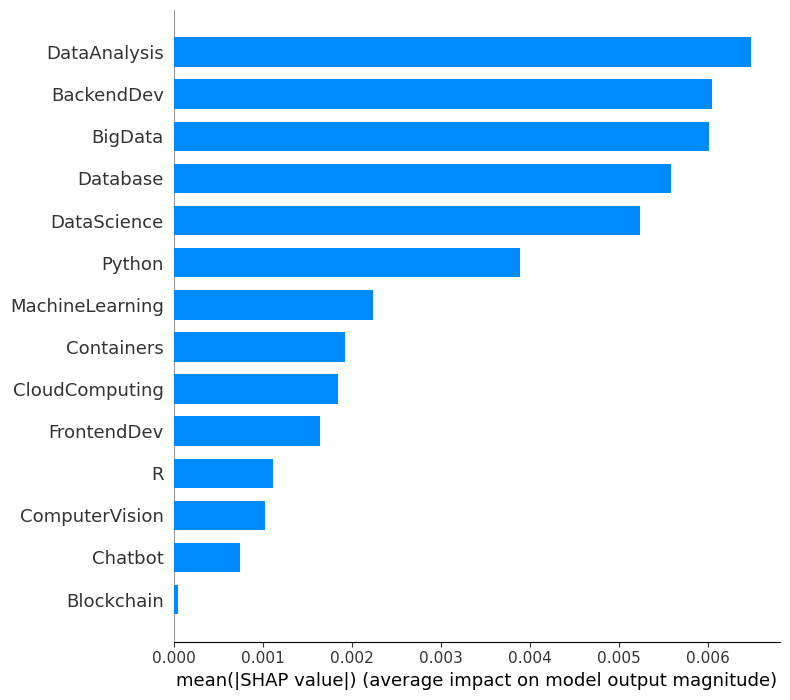

  Saved → /Users/moustafa/new_Xplaina/XplainaV301/figures/xai_shap_summary_user2.png


<Figure size 640x480 with 0 Axes>

In [18]:
# ── SHAP Summary Plot (global feature importance) ─────────────────────────────
if shap_vals is not None:
    print('SHAP Summary — global genre importance for content scores')
    shap.summary_plot(shap_vals, X_genres, plot_type='bar',
                      show=True, max_display=len(GENRE_COLS))
    plt.savefig(FIGURES_DIR / f'xai_shap_summary_user{USER_ID}.png',
                bbox_inches='tight', dpi=120)
    print(f'  Saved → {FIGURES_DIR / f"xai_shap_summary_user{USER_ID}.png"}')

📊  SHAP Waterfall — top item "BD0111EN"


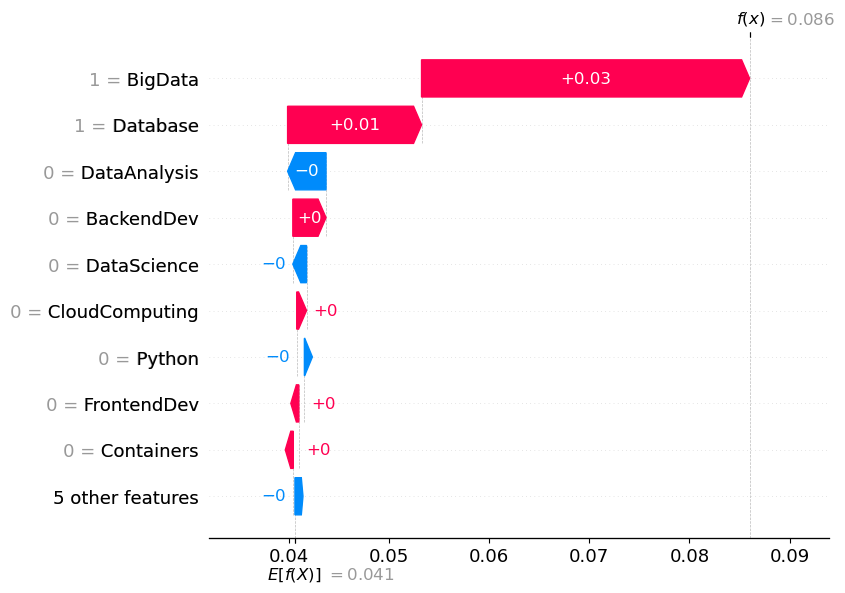

<Figure size 640x480 with 0 Axes>

In [19]:
# ── SHAP Waterfall for the top recommended item ───────────────────────────────
if shap_vals is not None and X_genres is not None:
    if TOP_ITEM in X_genres.index:
        item_idx = X_genres.index.get_loc(TOP_ITEM)
        print(f'📊  SHAP Waterfall — top item "{TOP_ITEM}"')

        sv = shap.Explanation(
            values        = shap_vals[item_idx],
            base_values   = shap_explainer.expected_value,
            data          = X_genres.iloc[item_idx].values,
            feature_names = GENRE_COLS,
        )
        shap.plots.waterfall(sv, show=True)
        plt.savefig(FIGURES_DIR / f'xai_shap_waterfall_{TOP_ITEM}.png',
                    bbox_inches='tight', dpi=120)
    else:
        print(f'{TOP_ITEM} not in genre feature matrix (might be a seen item).')

SHAP Beeswarm — distribution of genre impacts


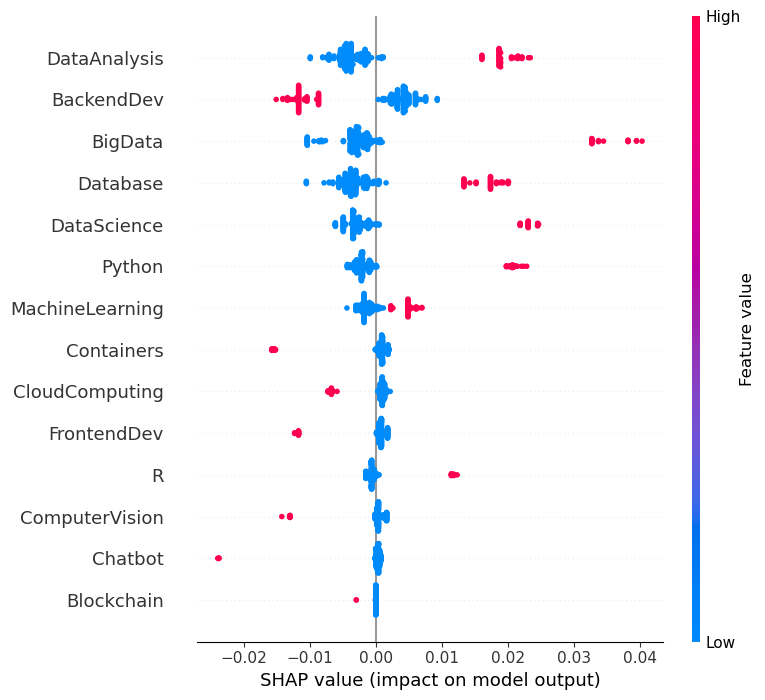

<Figure size 640x480 with 0 Axes>

In [20]:
# ── SHAP Beeswarm ─────────────────────────────────────────────────────────────
if shap_vals is not None:
    print('SHAP Beeswarm — distribution of genre impacts')
    shap.summary_plot(shap_vals, X_genres, show=True, max_display=len(GENRE_COLS))
    plt.savefig(FIGURES_DIR / f'xai_shap_beeswarm_user{USER_ID}.png',
                bbox_inches='tight', dpi=120)

---
## 8 · LIME — Local Explanation for a Single Item

In [21]:
from lime.lime_tabular import LimeTabularExplainer
from sklearn.linear_model import Ridge

def run_lime_content(
    user_id: int,
    item_id: str,
    train_df: pd.DataFrame,
    sim_df: pd.DataFrame,
    courses_df: pd.DataFrame,
    genre_cols: list[str],
    num_features: int = 10,
):
    """
    LIME explanation: which genres push the content score up/down
    for a specific (user, item) pair?
    """
    user_items = [
        i for i in train_df.loc[train_df['user'] == user_id, 'item']
        if i in sim_df.index
    ]
    content_scores = sim_df.loc[user_items].mean(axis=0)
    content_scores = content_scores.drop(labels=[
        i for i in user_items if i in content_scores.index
    ], errors='ignore')

    common = [c for c in content_scores.index if c in courses_df['COURSE_ID'].values]
    X = (
        courses_df.set_index('COURSE_ID')
        .loc[common, genre_cols]
        .fillna(0).astype(float)
    )
    y = content_scores.loc[common].values

    surrogate = Ridge(alpha=1.0)
    surrogate.fit(X, y)

    lime_exp = LimeTabularExplainer(
        training_data = X.values,
        feature_names = genre_cols,
        mode          = 'regression',
        discretize_continuous = False,
        random_state  = 42,
        verbose       = False,
    )

    if item_id not in X.index:
        return None, None, f'{item_id} not in feature matrix.'

    instance = X.loc[item_id].values
    exp = lime_exp.explain_instance(
        data_row     = instance,
        predict_fn   = surrogate.predict,
        num_features = num_features,
    )
    return exp, X, None


lime_exp, X_lime, lime_err = run_lime_content(
    USER_ID, TOP_ITEM, train_df, sim_df_tfidf, courses_df, GENRE_COLS
)

if lime_err:
    print(f'LIME: {lime_err}')
elif lime_exp:
    print(f'LIME explanation for item "{TOP_ITEM}"')
    print()
    print(lime_exp.as_list())

LIME explanation for item "BD0111EN"

[('BigData', 0.01156673698317615), ('DataAnalysis', 0.010284773375292653), ('DataScience', 0.009149824340201118), ('Database', 0.008621231750252211), ('Python', 0.007304625787843578), ('MachineLearning', 0.00575680457101489), ('R', 0.003061482636159052), ('ComputerVision', -0.0021073231492939482), ('BackendDev', -0.0017933361692129273), ('Containers', -0.0014825678030110307)]


  Saved → /Users/moustafa/new_Xplaina/XplainaV301/figures/xai_lime_BD0111EN_user2.png


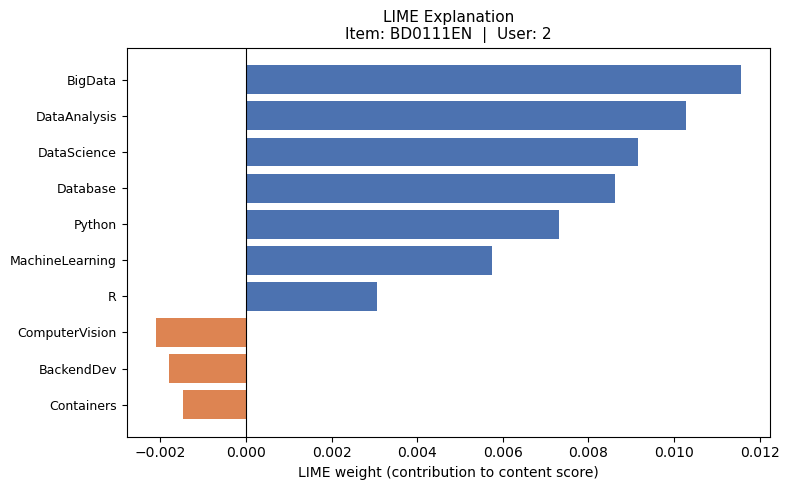

In [22]:
# ── LIME bar chart ────────────────────────────────────────────────────────────
if lime_exp:
    feat_list = lime_exp.as_list()
    feat_names = [f[0] for f in feat_list]
    feat_vals  = [f[1] for f in feat_list]
    colors = ['#4C72B0' if v > 0 else '#DD8452' for v in feat_vals]

    fig, ax = plt.subplots(figsize=(8, max(4, len(feat_names) * 0.5)))
    y_pos = np.arange(len(feat_names))
    ax.barh(y_pos, feat_vals[::-1], color=colors[::-1])
    ax.set_yticks(y_pos)
    ax.set_yticklabels(feat_names[::-1], fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('LIME weight (contribution to content score)')
    ax.set_title(f'LIME Explanation\nItem: {TOP_ITEM}  |  User: {USER_ID}', fontsize=11)
    plt.tight_layout()
    p = FIGURES_DIR / f'xai_lime_{TOP_ITEM}_user{USER_ID}.png'
    plt.savefig(p, bbox_inches='tight', dpi=120)
    print(f'  Saved → {p}')
    plt.show()

---
## 9 · Non-Hybrid Model Explainability

Explains the **Item-KNN**, **TF-IDF similarity**, and **BoW similarity**  
models individually — each with its own SHAP and LIME pass.

### 9-A  Item-KNN Explanation

In [23]:
def explain_item_knn(
    user_id: int,
    item_id: str,
    train_utility: pd.DataFrame,
    k: int = 20,
    top_k: int = 5,
) -> dict:
    """
    For Item-KNN: which similar items (by user co-rating pattern) that
    the user has already rated drive the prediction for item_id?
    """
    items = train_utility.columns.tolist()
    mat   = train_utility.fillna(0).values.astype(np.float32)

    if item_id not in items:
        return {'error': f'{item_id} not in utility matrix columns.'}

    item_mat = mat.T
    i_idx = items.index(item_id)

    knn = NearestNeighbors(n_neighbors=min(k + 1, len(items)),
                           metric='cosine', algorithm='brute')
    knn.fit(item_mat)
    dists, idxs = knn.kneighbors([item_mat[i_idx]])

    neighbour_items = [items[i] for i in idxs[0][1:]]
    sims = 1 - dists[0][1:]

    # User's ratings on neighbour items
    if user_id not in train_utility.index:
        return {'error': f'User {user_id} not in utility matrix.'}

    user_ratings = [
        float(train_utility.loc[user_id, n])
        if n in train_utility.columns else np.nan
        for n in neighbour_items
    ]

    df = pd.DataFrame({
        'neighbour_item' : neighbour_items,
        'item_similarity': sims,
        'user_rating'    : user_ratings,
    }).dropna().query('user_rating > 0').nlargest(top_k, 'item_similarity')

    weighted = (df['item_similarity'] * df['user_rating']).sum()
    weight   = df['item_similarity'].sum()
    predicted = weighted / weight if weight > 0 else 0.0

    return {
        'user': user_id,
        'item': item_id,
        'top_contributors': df.reset_index(drop=True),
        'predicted_rating': float(predicted),
        'narrative': (
            f"Item-KNN recommends '{item_id}' because user {user_id} rated "
            f"{len(df)} item(s) with similar co-rating patterns highly. "
            f"Weighted predicted rating: {predicted:.2f}."
        )
    }


item_knn_exp = explain_item_knn(USER_ID, TOP_ITEM, train_utility)
print('\nItem-KNN Explanation')
print(f'   {item_knn_exp.get("narrative", item_knn_exp.get("error"))}')
if 'top_contributors' in item_knn_exp:
    display(item_knn_exp['top_contributors'])


Item-KNN Explanation
   Item-KNN recommends 'BD0111EN' because user 2 rated 5 item(s) with similar co-rating patterns highly. Weighted predicted rating: 3.00.


,neighbour_item,item_similarity,user_rating
0,BD0101EN,0.571592,3.0
1,BD0211EN,0.528559,3.0
2,BD0131EN,0.365065,3.0
3,BD0141EN,0.363731,3.0
4,PY0101EN,0.350616,3.0


### 9-B  TF-IDF Similarity Model — SHAP & LIME

In [24]:
def run_shap_for_sim_model(
    user_id: int,
    sim_df: pd.DataFrame,
    train_df: pd.DataFrame,
    courses_df: pd.DataFrame,
    genre_cols: list[str],
    label: str = 'TF-IDF',
):
    """
    Fit Ridge(genre → content_score) on the given sim_df and return SHAP values.
    Works identically for TF-IDF or BoW similarity matrices.
    """
    user_items = [
        i for i in train_df.loc[train_df['user'] == user_id, 'item']
        if i in sim_df.index
    ]
    if not user_items:
        print(f'No user items in {label} sim_df.')
        return None, None, None

    scores = sim_df.loc[user_items].mean(axis=0)
    scores = scores.drop(labels=[i for i in user_items if i in scores.index], errors='ignore')
    common = [c for c in scores.index if c in courses_df['COURSE_ID'].values]

    X = courses_df.set_index('COURSE_ID').loc[common, genre_cols].fillna(0).astype(float)
    y = scores.loc[common].values

    model = Ridge(alpha=1.0)
    model.fit(X, y)

    explainer   = shap.LinearExplainer(model, X,
                                        feature_perturbation='correlation_dependent')
    shap_values = explainer.shap_values(X)

    print(f'SHAP ready for {label}  ({len(X)} items × {len(genre_cols)} genres)')
    return explainer, shap_values, X


# TF-IDF sim model (standalone — uses standalone tfidf_similarity.pkl)
if tfidf_similarity is not None:
    print('── TF-IDF Similarity Model ──')
    tfidf_exp, tfidf_shap, X_tfidf = run_shap_for_sim_model(
        USER_ID, tfidf_similarity, train_df, courses_df, GENRE_COLS, label='TF-IDF'
    )
else:
    print('tfidf_similarity.pkl not loaded — skipping standalone TF-IDF SHAP.')
    tfidf_exp = tfidf_shap = X_tfidf = None

# BoW sim model
if bow_similarity is not None:
    print('\n── BoW Similarity Model ──')
    bow_exp, bow_shap, X_bow = run_shap_for_sim_model(
        USER_ID, bow_similarity, train_df, courses_df, GENRE_COLS, label='BoW'
    )
else:
    print('bow_similarity.pkl not loaded — skipping BoW SHAP.')
    bow_exp = bow_shap = X_bow = None

── TF-IDF Similarity Model ──


Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

SHAP ready for TF-IDF  (258 items × 14 genres)

── BoW Similarity Model ──


Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

SHAP ready for BoW  (258 items × 14 genres)


  Saved → /Users/moustafa/new_Xplaina/XplainaV301/figures/xai_shap_tfidf_vs_bow_user2.png


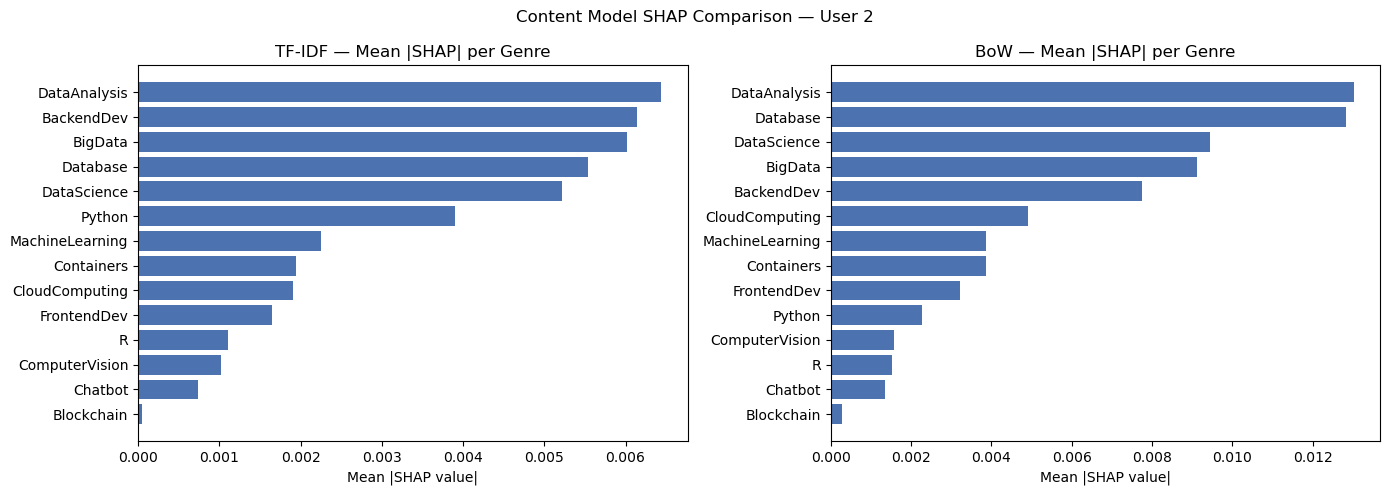

In [25]:
# ── Side-by-side SHAP summary: TF-IDF vs BoW ─────────────────────────────────
if tfidf_shap is not None and bow_shap is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, shap_v, X, label in [
        (axes[0], tfidf_shap, X_tfidf, 'TF-IDF'),
        (axes[1], bow_shap,   X_bow,   'BoW'),
    ]:
        mean_abs = np.abs(shap_v).mean(axis=0)
        order    = np.argsort(mean_abs)[::-1]
        ax.barh(
            np.array(GENRE_COLS)[order][::-1],
            mean_abs[order][::-1],
            color='#4C72B0'
        )
        ax.set_title(f'{label} — Mean |SHAP| per Genre')
        ax.set_xlabel('Mean |SHAP value|')

    fig.suptitle(f'Content Model SHAP Comparison — User {USER_ID}', fontsize=12)
    plt.tight_layout()
    p = FIGURES_DIR / f'xai_shap_tfidf_vs_bow_user{USER_ID}.png'
    plt.savefig(p, bbox_inches='tight', dpi=120)
    print(f'  Saved → {p}')
    plt.show()
elif tfidf_shap is not None:
    shap.summary_plot(tfidf_shap, X_tfidf, plot_type='bar',
                      show=True, max_display=len(GENRE_COLS))

In [26]:
# ── LIME for standalone TF-IDF model ─────────────────────────────────────────
if tfidf_similarity is not None:
    lime_tfidf, X_lt, err_lt = run_lime_content(
        USER_ID, TOP_ITEM, train_df, tfidf_similarity, courses_df, GENRE_COLS
    )
    if lime_tfidf:
        print(f'LIME (TF-IDF standalone) for item "{TOP_ITEM}":')
        print(lime_tfidf.as_list())
    else:
        print(f'LIME TF-IDF: {err_lt}')

# ── LIME for BoW model ────────────────────────────────────────────────────────
if bow_similarity is not None:
    lime_bow, X_lb, err_lb = run_lime_content(
        USER_ID, TOP_ITEM, train_df, bow_similarity, courses_df, GENRE_COLS
    )
    if lime_bow:
        print(f'\nLIME (BoW standalone) for item "{TOP_ITEM}":')
        print(lime_bow.as_list())
    else:
        print(f'LIME BoW: {err_lb}')

LIME (TF-IDF standalone) for item "BD0111EN":
[('BigData', 0.01156673698317615), ('DataAnalysis', 0.010284773375292653), ('DataScience', 0.009149824340201118), ('Database', 0.008621231750252211), ('Python', 0.007304625787843578), ('MachineLearning', 0.00575680457101489), ('R', 0.003061482636159052), ('ComputerVision', -0.0021073231492939482), ('BackendDev', -0.0017933361692129273), ('Containers', -0.0014825678030110307)]

LIME (BoW standalone) for item "BD0111EN":
[('DataAnalysis', 0.02159518930308623), ('Database', 0.02127682208973809), ('DataScience', 0.01737269922986852), ('BigData', 0.01614401105314793), ('MachineLearning', 0.011139987665440929), ('Python', 0.004585109344485228), ('R', 0.003971614891350807), ('Containers', -0.003732646486451687), ('CloudComputing', -0.0026932562537141215), ('BackendDev', 0.002217080998223565)]


---
## 10 · Consolidated Explanation Report

Assemble everything into a single structured dict that can be  
serialised to JSON or logged to a monitoring system.

In [27]:
def build_explanation_report(
    user_id: int,
    top_df: pd.DataFrame,
    alpha: float,
    cf_explain: dict,
    content_explain: dict,
    item_knn_explain: dict,
    shap_genre_importance: dict | None = None,
    lime_features: list | None = None,
) -> dict:
    recs = top_df[['COURSE_ID', 'cf_score', 'content_score', 'hybrid_score']].copy()
    recs['cf_contribution']      = (recs['cf_score']      * alpha).round(4)
    recs['content_contribution'] = (recs['content_score'] * (1 - alpha)).round(4)

    report = {
        'user_id'       : user_id,
        'alpha'         : alpha,
        'recommendations': recs.to_dict(orient='records'),
        'cf_explanation': {
            'narrative'   : cf_explain.get('narrative', cf_explain.get('error')),
            'contributors': (
                cf_explain['top_contributors'].to_dict(orient='records')
                if 'top_contributors' in cf_explain else []
            ),
        },
        'content_explanation': {
            'narrative'        : content_explain.get('narrative', content_explain.get('error')),
            'item_genres'      : content_explain.get('item_genres', []),
            'top_similar_seen' : content_explain.get('top_similar_seen', []),
            'shared_genres'    : content_explain.get('all_shared_genres', []),
        },
        'item_knn_explanation': {
            'narrative'   : item_knn_explain.get('narrative', item_knn_explain.get('error')),
            'contributors': (
                item_knn_explain['top_contributors'].to_dict(orient='records')
                if 'top_contributors' in item_knn_explain else []
            ),
        },
        'shap_genre_importance': shap_genre_importance or {},
        'lime_top_features'    : lime_features or [],
    }
    return report


# Build SHAP importance dict
shap_importance = None
if shap_vals is not None:
    mean_abs = np.abs(shap_vals).mean(axis=0)
    shap_importance = dict(zip(GENRE_COLS, mean_abs.tolist()))

lime_features_list = lime_exp.as_list() if lime_exp else []

report = build_explanation_report(
    user_id         = USER_ID,
    top_df          = top_df,
    alpha           = ALPHA,
    cf_explain      = cf_explain,
    content_explain = content_explain,
    item_knn_explain= item_knn_exp,
    shap_genre_importance = shap_importance,
    lime_features   = lime_features_list,
)

# ── Save JSON report ──────────────────────────────────────────────────────────
report_path = RESULTS_DIR / f'xai_report_user{USER_ID}.json'
with open(report_path, 'w') as f:
    json.dump(report, f, indent=2, default=str)
print(f'Explanation report saved → {report_path}')

# ── Preview ───────────────────────────────────────────────────────────────────
print('\n📋  Report preview:')
print(json.dumps({
    'user_id' : report['user_id'],
    'alpha'   : report['alpha'],
    'top_item_breakdown': report['recommendations'][0],
    'cf_narrative'     : report['cf_explanation']['narrative'],
    'content_narrative': report['content_explanation']['narrative'],
    'item_knn_narrative': report['item_knn_explanation']['narrative'],
    'top_shap_genre'   : (
        max(report['shap_genre_importance'], key=report['shap_genre_importance'].get)
        if report['shap_genre_importance'] else 'N/A'
    ),
    'lime_top_feature' : report['lime_top_features'][0] if report['lime_top_features'] else 'N/A',
}, indent=2))

Explanation report saved → /Users/moustafa/new_Xplaina/XplainaV301/results/xai_report_user2.json

📋  Report preview:
{
  "user_id": 2,
  "alpha": 0.5,
  "top_item_breakdown": {
    "COURSE_ID": "BD0111EN",
    "cf_score": 0.9999998211860657,
    "content_score": 0.9108184225315525,
    "hybrid_score": 0.9554091218588091,
    "cf_contribution": 0.5,
    "content_contribution": 0.4554
  },
  "cf_narrative": "User 2 is recommended 'BD0111EN' because 5 similar user(s) rated it highly. Weighted predicted rating: 3.00.",
  "content_narrative": "'BD0111EN' is recommended because it shares the genre(s) ['BigData', 'Database'] with courses the user has already engaged with, giving an average similarity of 0.553.",
  "item_knn_narrative": "Item-KNN recommends 'BD0111EN' because user 2 rated 5 item(s) with similar co-rating patterns highly. Weighted predicted rating: 3.00.",
  "top_shap_genre": "DataAnalysis",
  "lime_top_feature": [
    "BigData",
    0.01156673698317615
  ]
}


---
## 11 · Batch Explainability — Multiple Users

Run the full pipeline for several users and save per-user reports.

In [28]:
def explain_batch(
    user_ids: list[int],
    train_df: pd.DataFrame,
    cf_predictions: dict,
    sim_df: pd.DataFrame,
    courses_df: pd.DataFrame,
    genre_cols: list[str],
    alpha: float,
    top_n: int,
    results_dir: Path,
) -> pd.DataFrame:
    """
    Run explanation for each user_id and save individual JSON reports.
    Returns a summary DataFrame.
    """
    train_utility = train_df.pivot_table(index='user', columns='item', values='rating')
    rows = []

    for uid in user_ids:
        if uid not in cf_predictions:
            print(f' user {uid} not in CF predictions — skipping.')
            continue

        result = hybrid_scores_for_user(
            user=uid, train_df=train_df, cf_predictions=cf_predictions,
            sim_df=sim_df, alpha=alpha, top_n=top_n,
            normalize=True, return_components=True,
        )
        if not result['hybrid_top'].empty:
            top_item = result['hybrid_top'].index[0]
            hs = float(result['hybrid_top'].iloc[0])
            cf_s  = float(result['cf_full'].get(top_item, 0.0))
            cb_s  = float(result['content_full'].get(top_item, 0.0))
        else:
            top_item, hs, cf_s, cb_s = None, 0.0, 0.0, 0.0

        row = {
            'user_id'       : uid,
            'top_item'      : top_item,
            'hybrid_score'  : round(hs, 4),
            'cf_score'      : round(cf_s, 4),
            'content_score' : round(cb_s, 4),
            'n_seen'        : len(result['seen_items']),
        }
        rows.append(row)
        print(f'  user {uid}  → top_item={top_item}  hybrid={hs:.3f}')

    summary = pd.DataFrame(rows)
    out_path = results_dir / 'xai_batch_summary.csv'
    summary.to_csv(out_path, index=False)
    print(f'\nBatch summary saved → {out_path}')
    return summary


# ── Run batch for a sample of users ──────────────────────────────────────────
sample_users = sorted(list(known_users & set(pred_user_knn.keys())))[:5]
print(f'Running batch explanation for users: {sample_users}')
batch_summary = explain_batch(
    user_ids      = sample_users,
    train_df      = train_df,
    cf_predictions= pred_user_knn,
    sim_df        = sim_df_tfidf,
    courses_df    = courses_df,
    genre_cols    = GENRE_COLS,
    alpha         = BEST_ALPHA,
    top_n         = TOP_N,
    results_dir   = RESULTS_DIR,
)
display(batch_summary)

Running batch explanation for users: [-181, -180, -179, -178, -177]
  user -181  → top_item=excourse89  hybrid=0.352
  user -180  → top_item=excourse91  hybrid=0.305
  user -179  → top_item=excourse92  hybrid=0.305
  user -178  → top_item=excourse87  hybrid=0.324
  user -177  → top_item=excourse93  hybrid=0.352

Batch summary saved → /Users/moustafa/new_Xplaina/XplainaV301/results/xai_batch_summary.csv


,user_id,top_item,hybrid_score,cf_score,content_score,n_seen
0,-181,excourse89,0.3519,0.0,0.7037,1
1,-180,excourse91,0.3053,0.0,0.6105,1
2,-179,excourse92,0.3053,0.0,0.6105,1
3,-178,excourse87,0.3245,0.0,0.6490,1
4,-177,excourse93,0.3519,0.0,0.7037,1


---
## 12 · Summary Dashboard

  Saved → /Users/moustafa/new_Xplaina/XplainaV301/figures/xai_dashboard_user2.png


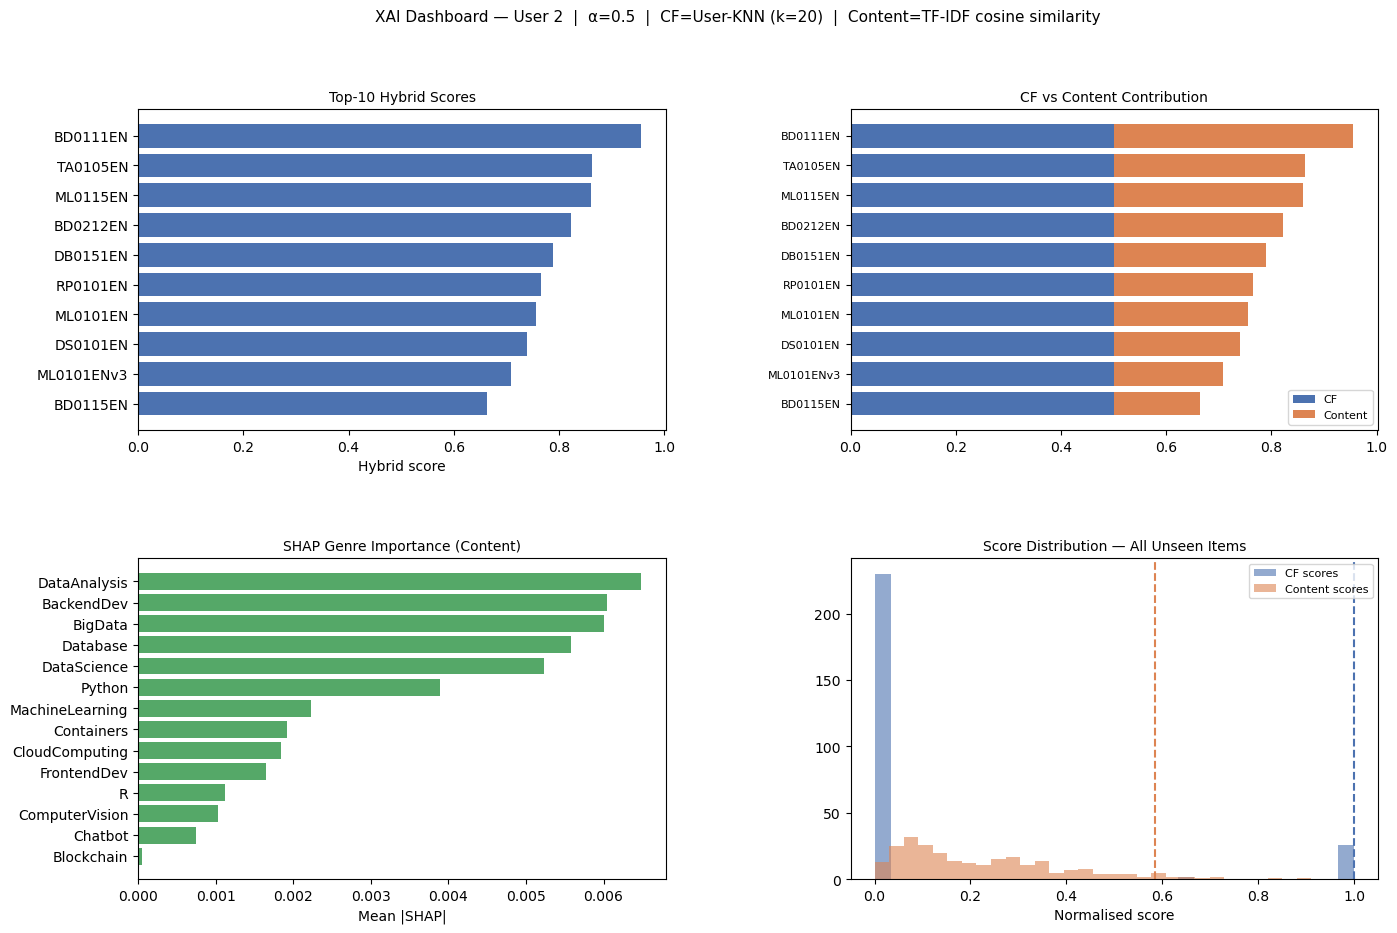

In [29]:
def plot_xai_dashboard(
    top_df: pd.DataFrame,
    shap_importance: dict | None,
    user_id: int,
    alpha: float,
    save_dir: Path | None = None,
):
    """4-panel XAI summary dashboard."""
    fig = plt.figure(figsize=(16, 10))
    gs  = fig.add_gridspec(2, 2, hspace=0.4, wspace=0.35)

    # ── Panel 1: Hybrid score bar ─────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    df  = top_df.sort_values('hybrid_score')
    ax1.barh(df['COURSE_ID'].astype(str), df['hybrid_score'], color='#4C72B0')
    ax1.set_title(f'Top-{len(df)} Hybrid Scores', fontsize=10)
    ax1.set_xlabel('Hybrid score')

    # ── Panel 2: CF vs Content contribution ──────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    cf_c  = (df['cf_score']      * alpha).fillna(0)
    cb_c  = (df['content_score'] * (1 - alpha)).fillna(0)
    y = np.arange(len(df))
    ax2.barh(y, cf_c, color='#4C72B0', label='CF')
    ax2.barh(y, cb_c, left=cf_c, color='#DD8452', label='Content')
    ax2.set_yticks(y)
    ax2.set_yticklabels(df['COURSE_ID'].astype(str), fontsize=8)
    ax2.set_title('CF vs Content Contribution', fontsize=10)
    ax2.legend(fontsize=8)

    # ── Panel 3: SHAP genre importance ────────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    if shap_importance:
        si = pd.Series(shap_importance).sort_values()
        ax3.barh(si.index, si.values, color='#55A868')
        ax3.set_title('SHAP Genre Importance (Content)', fontsize=10)
        ax3.set_xlabel('Mean |SHAP|')
    else:
        ax3.text(0.5, 0.5, 'SHAP not available', ha='center', va='center')
        ax3.axis('off')

    # ── Panel 4: Score distribution (CF vs Content) ───────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.hist(cf_full.values,      bins=30, alpha=0.6, label='CF scores',      color='#4C72B0')
    ax4.hist(content_full.values, bins=30, alpha=0.6, label='Content scores', color='#DD8452')
    ax4.axvline(cf_full.loc[top_df['COURSE_ID']].mean(),
                color='#4C72B0', linestyle='--', linewidth=1.5)
    ax4.axvline(content_full.loc[top_df['COURSE_ID']].mean(),
                color='#DD8452', linestyle='--', linewidth=1.5)
    ax4.set_title('Score Distribution — All Unseen Items', fontsize=10)
    ax4.set_xlabel('Normalised score')
    ax4.legend(fontsize=8)

    fig.suptitle(
        f'XAI Dashboard — User {user_id}  |  α={alpha}  |  CF={CF_MODEL}  |  Content={CONTENT_MODEL}',
        fontsize=11
    )
    if save_dir:
        p = Path(save_dir) / f'xai_dashboard_user{user_id}.png'
        plt.savefig(p, bbox_inches='tight', dpi=120)
        print(f'  Saved → {p}')
    plt.show()


plot_xai_dashboard(top_df, shap_importance, USER_ID, ALPHA, save_dir=FIGURES_DIR)

---
## ✅ Pipeline Summary

| Step | What it does |
|------|--------------|
| **2** | JSON → internal model input |
| **3** | Single hybrid pass, captures `cf_full` + `content_full` |
| **4** | Score breakdown bar (CF contribution vs Content contribution) |
| **5** | CF explanation — similar users + their ratings |
| **6** | Content explanation — shared genres / keyword similarity |
| **7** | SHAP — global & per-item genre importance for hybrid content scores |
| **8** | LIME — local genre importance for a specific (user, item) |
| **9** | Non-hybrid models: Item-KNN, standalone TF-IDF, BoW — each with SHAP + LIME |
| **10** | Structured JSON report — loggable / API-serialisable |
| **11** | Batch mode — explain N users, save CSV summary |
| **12** | 4-panel XAI dashboard figure |

**No training notebook was modified.**  
**The hybrid model runs exactly once per request.**